In [44]:
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt

import numpy as np

FILE_PATH = "/Users/rupesh/Downloads/ngc5195_drc/hlsp_legus_hst_acs_ngc5195_f435w_v1_drc.fits"
# TiDE simulations at 9.5Mpc
SIM_FILES = {"100":"tide_simulations_9_5mpc/tde_lightcurve_bh_100Msun.csv",
            "1000":"tide_simulations_9_5mpc/tde_lightcurve_bh_1000Msun.csv",
            "10000":"tide_simulations_9_5mpc/tde_lightcurve_bh_10000Msun.csv",
            "100000":"tide_simulations_9_5mpc/tde_lightcurve_bh_100000Msun.csv",
            "1000000":"tide_simulations_9_5mpc/tde_lightcurve_bh_1000000Msun.csv"}


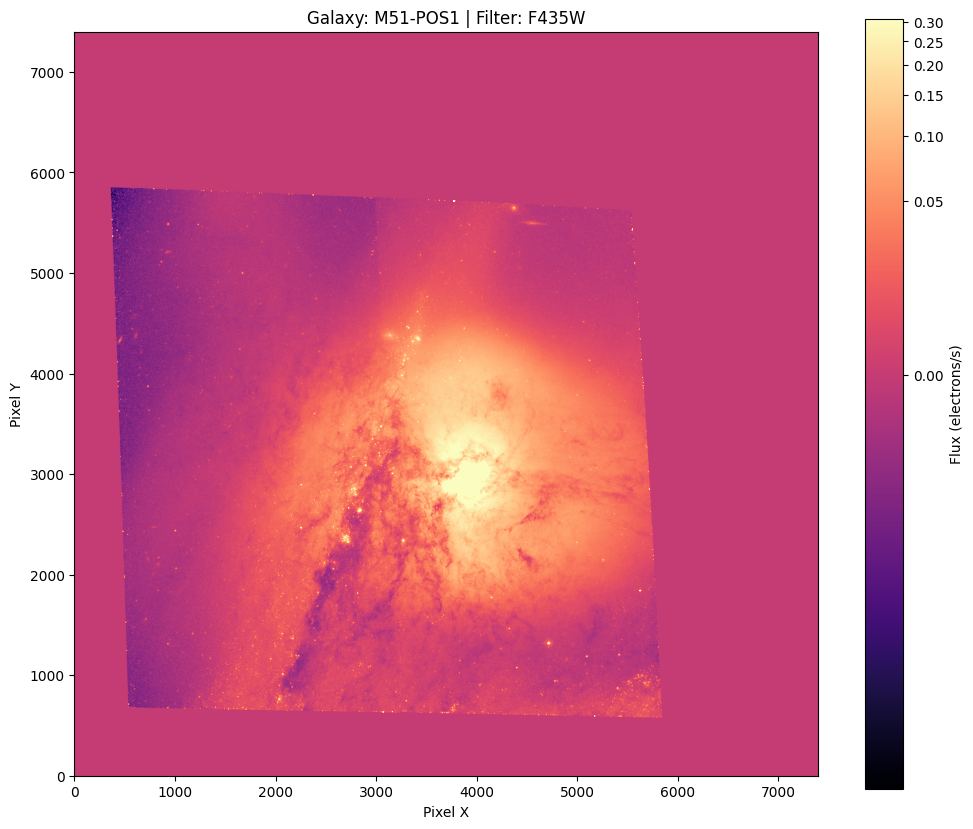

In [45]:
def load_fits(filts_file_path):
    with fits.open(filts_file_path) as hdul:
        header = hdul[0].header
        counts_data = hdul[0].data
        return header, counts_data


from astropy.visualization import (ImageNormalize, LogStretch, 
                                   PercentileInterval)

header, electrons_count = load_fits(FILE_PATH)
    
norm = ImageNormalize(electrons_count, interval=PercentileInterval(99.5),
                     stretch=LogStretch())

plt.figure(figsize=(12, 10))
plt.imshow(electrons_count, cmap='magma', norm=norm, origin='lower')

plt.colorbar(label='Flux (electrons/s)')
plt.title(f"Galaxy: {header['TARGNAME']} | Filter: {header['FILTER']}")
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()


In [46]:
def mosaic_electron_s_to_mjy(counts, header):
    """HST image electron/s counts to flux density in mJy"""
    photflam, photplam = header['PHOTFLAM'], header['PHOTPLAM']
    C_A_S = 2.99792458e18
    return (counts * photflam * (photplam ** 2 / C_A_S)) / 1e-26

galaxy_flux_mjy_original = mosaic_electron_s_to_mjy(electrons_count, header)
tide_simulation_df = pd.read_csv(SIM_FILES["100"])

In [47]:
INJECTION_COORDINATE = (3000, 3000)
SNR_THRESHOLD = 5.0

def add_noise(flux_mjy, header):
    exptime = header['EXPTIME']
    photflam = header['PHOTFLAM']
    photplam = header['PHOTPLAM']
    read_noise_e = 5.0 
    c_A_s = 2.9979e18
    
    # mJy -> electrons / sec
    conversion_factor = (photflam * (photplam**2 / c_A_s)) / (exptime * 1e-26)
    electrons = flux_mjy / conversion_factor
    
    # poisson + read noise
    poisson_noisy = np.random.poisson(np.maximum(electrons, 0))
    if isinstance(electrons, np.ndarray):
        rn_map = np.random.normal(0, read_noise_e, electrons.shape)
    else:
        rn_map = np.random.normal(0, read_noise_e)
        
    final_electrons = poisson_noisy + rn_map
    return final_electrons * conversion_factor, read_noise_e * conversion_factor

galaxy_flux_noise, read_noise_floor_mjy = add_noise(galaxy_flux_mjy_original, header)
Y, X = INJECTION_COORDINATE
base_flux = galaxy_flux_mjy_original[Y, X]
local_noise = galaxy_flux_noise[Y-20:Y+20, X-20:X+20]
sigma_background = np.std(local_noise) 
threshold = base_flux + (SNR_THRESHOLD * sigma_background)
alerts = 0
time_days_snr = []
distance_results = []

for each_bh_val in tide_simulation_df['flux_mjy'].values:
    flux_combined = base_flux + each_bh_val
    flux_combined_noise, _ = add_noise(flux_combined, header)
    if flux_combined_noise >= threshold:
            alerts += 1
    time_days_snr.append((flux_combined_noise - base_flux) / sigma_background)
    
efficiency = (alerts / len(tide_simulation_df)) * 100
distance_results.append({
     "distance": 9.5,
    'efficiency': efficiency,
    'snr': np.array(time_days_snr),
    'sigma': sigma_background
})

print(f"Dist: {9.5} Mpc | Efficiency: {efficiency:.1f}% | Sigma: {sigma_background:.2e}")



Dist: 9.5 Mpc | Efficiency: 100.0% | Sigma: 9.88e-07


In [48]:

def run_simulation_for_distances(distance_new, distance_original,
        gal_clean_orig, simulation_df, header, coords, snr_thresh=5.0):
    y, x = coords
    
    distance_scaling = (distance_original / distance_new) ** 2
    
    galaxy_flux_scaled = gal_clean_orig * distance_scaling
    bh_flux_scaled = simulation_df['flux_mjy'].values * distance_scaling
    
    base_flux = galaxy_flux_scaled[y, x]
    
    galaxy_flux_noise, _ = add_noise(galaxy_flux_scaled, header)
    local_noise = galaxy_flux_noise[y-20:y+20, x-20:x+20]
    sigma_background = np.std(local_noise) 
    
    threshold = base_flux + (snr_thresh * sigma_background)
    alerts = 0
    time_days_snr = []
    
    for bh_val in bh_flux_scaled:
        flux_combined_clean = base_flux + bh_val
        flux_combined_noise, _ = add_noise(flux_combined_clean, header)
        
        if flux_combined_noise >= threshold:
            alerts += 1
            
        time_days_snr.append((flux_combined_noise - base_flux) / sigma_background)
    
    return {
        "distance_mpc": distance_new,
        "efficiency": (alerts / len(simulation_df)) * 100,
        "alerts_count": alerts,
        "avg_snr": np.mean(time_days_snr),
        "snr_series": np.array(time_days_snr),
        "sigma_background": sigma_background,
        "base_flux": base_flux
    }


distances_list = [50, 100, 200, 400, 800, 1000, 1500]
distance_original = 9.5
all_results = []

for each_distance in distances_list:
    res = run_simulation_for_distances(
        distance_new=each_distance, 
        distance_original=distance_original, 
        gal_clean_orig=galaxy_flux_mjy_original, 
        simulation_df=tide_simulation_df, 
        header=header, 
        coords=INJECTION_COORDINATE
    )
    all_results.append(res)
    print(
        f"Distance: {each_distance} Mpc\n"
        f"Efficiency: {res['efficiency']:.1f}%\n"
        f"Sigma: {res['sigma_background']:.2e}\n"
    )

Distance: 50 Mpc
Efficiency: 100.0%
Sigma: 3.57e-07

Distance: 100 Mpc
Efficiency: 99.8%
Sigma: 3.58e-07

Distance: 200 Mpc
Efficiency: 62.0%
Sigma: 3.57e-07

Distance: 400 Mpc
Efficiency: 34.0%
Sigma: 3.55e-07

Distance: 800 Mpc
Efficiency: 20.2%
Sigma: 3.45e-07

Distance: 1000 Mpc
Efficiency: 16.4%
Sigma: 3.55e-07

Distance: 1500 Mpc
Efficiency: 11.7%
Sigma: 3.53e-07



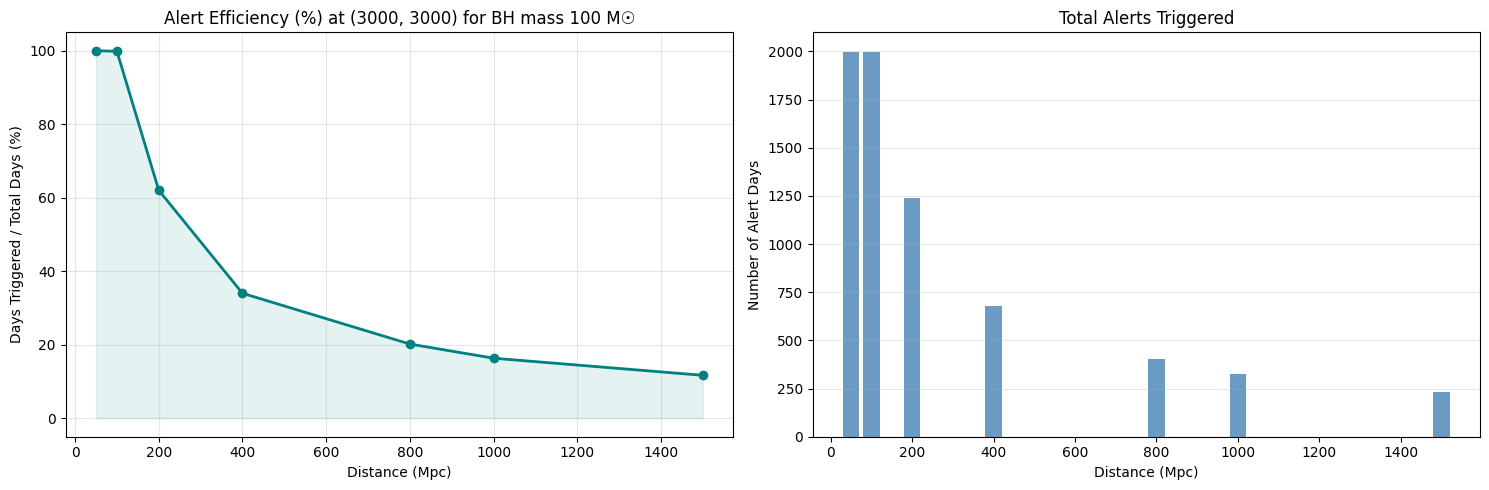

In [49]:
dist_plot = [r['distance_mpc'] for r in all_results]
eff_plot = [r['efficiency'] for r in all_results]
alert_counts = [r['alerts_count'] for r in all_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(dist_plot, eff_plot, marker='o', linestyle='-', color='teal', linewidth=2)
ax1.fill_between(dist_plot, eff_plot, color='teal', alpha=0.1)
ax1.set_title(f"Alert Efficiency (%) at {INJECTION_COORDINATE} for BH mass 100 M☉", fontsize=12)
ax1.set_xlabel("Distance (Mpc)")
ax1.set_ylabel("Days Triggered / Total Days (%)")
ax1.grid(alpha=0.3)

ax2.bar(dist_plot, alert_counts, color='steelblue', alpha=0.8, width=40)
ax2.set_title("Total Alerts Triggered", fontsize=12)
ax2.set_xlabel("Distance (Mpc)")
ax2.set_ylabel("Number of Alert Days")
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:


distances_list = [50, 100, 200, 400, 800, 1000, 1500]
distance_original = 9.5

all_bh_mass_results = {}
for bh_mass, simulation_file in SIM_FILES.items():
    bh_mass_result = []

    simulation_df = pd.read_csv(SIM_FILES[bh_mass])
    for each_distance in distances_list:
        res = run_simulation_for_distances(
            distance_new=each_distance, 
            distance_original=distance_original, 
            gal_clean_orig=galaxy_flux_mjy_original, 
            simulation_df=simulation_df, 
            header=header, 
            coords=INJECTION_COORDINATE
        )
        bh_mass_result.append(res)
        print(f"BH Mass: {bh_mass} M☉ | Dist: {each_distance} Mpc | Detection Efficiency: {res['efficiency']:.1f}% | Sigma: {res['sigma_background']:.2e}")
    all_bh_mass_results[bh_mass] = bh_mass_result

BH Mass: 100 M☉ | Dist: 50 Mpc | Detection Efficiency: 100.0% | Sigma: 3.67e-07
BH Mass: 100 M☉ | Dist: 100 Mpc | Detection Efficiency: 99.8% | Sigma: 3.56e-07
BH Mass: 100 M☉ | Dist: 200 Mpc | Detection Efficiency: 62.1% | Sigma: 3.55e-07
BH Mass: 100 M☉ | Dist: 400 Mpc | Detection Efficiency: 34.4% | Sigma: 3.63e-07
BH Mass: 100 M☉ | Dist: 800 Mpc | Detection Efficiency: 19.7% | Sigma: 3.44e-07
BH Mass: 100 M☉ | Dist: 1000 Mpc | Detection Efficiency: 16.6% | Sigma: 3.52e-07
BH Mass: 100 M☉ | Dist: 1500 Mpc | Detection Efficiency: 11.6% | Sigma: 3.70e-07
BH Mass: 1000 M☉ | Dist: 50 Mpc | Detection Efficiency: 100.0% | Sigma: 3.68e-07
BH Mass: 1000 M☉ | Dist: 100 Mpc | Detection Efficiency: 100.0% | Sigma: 3.59e-07
BH Mass: 1000 M☉ | Dist: 200 Mpc | Detection Efficiency: 100.0% | Sigma: 3.58e-07
BH Mass: 1000 M☉ | Dist: 400 Mpc | Detection Efficiency: 76.9% | Sigma: 3.58e-07
BH Mass: 1000 M☉ | Dist: 800 Mpc | Detection Efficiency: 38.2% | Sigma: 3.54e-07
BH Mass: 1000 M☉ | Dist: 1000 M

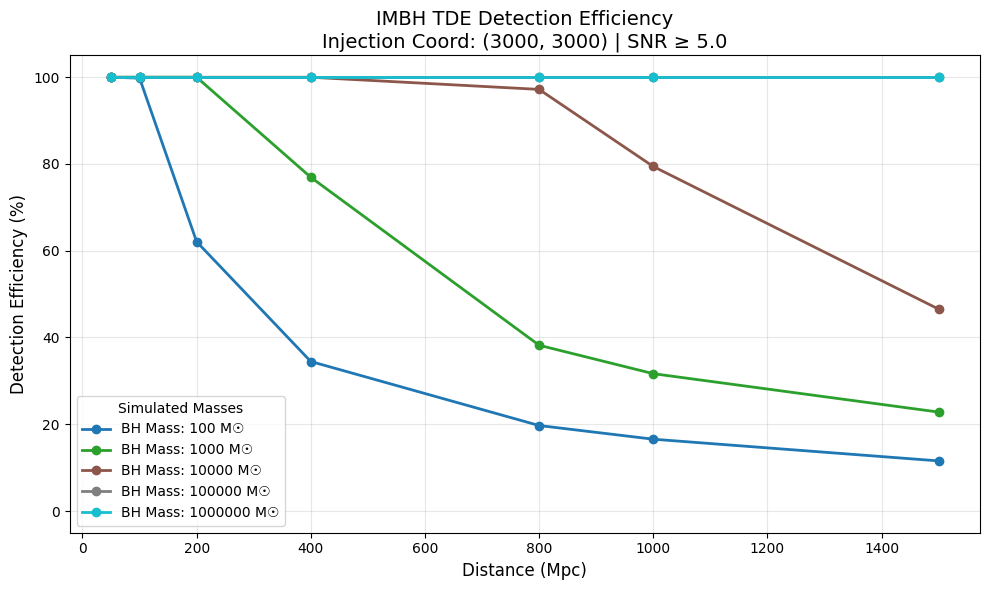

In [51]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_bh_mass_results)))
for i, (bh_mass, results) in enumerate(all_bh_mass_results.items()):
    distances = [res['distance_mpc'] for res in results]
    efficiencies = [res['efficiency'] for res in results]
    plt.plot(distances, efficiencies, marker='o', label=f"BH Mass: {bh_mass} M☉", color=colors[i], linewidth=2)

plt.title(
    f"IMBH TDE Detection Efficiency\n"
    f"Injection Coord: {INJECTION_COORDINATE} | SNR ≥ {SNR_THRESHOLD}",
    fontsize=14
)
plt.xlabel("Distance (Mpc)", fontsize=12)
plt.ylabel("Detection Efficiency (%)", fontsize=12)
plt.ylim(-5, 105) 
plt.grid(alpha=0.3)
plt.legend(title="Simulated Masses", frameon=True)

plt.tight_layout()
plt.show()